<a href="https://colab.research.google.com/github/joaomerjam/ECON3916-33674-Statistical-Machine-Learning/blob/main/Assignemnt%203/Econ_3916_Assignment_3_Causal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:

np.random.seed(42)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
print("Environment initialized.")

Environment initialized.


In [19]:
# Data Generating Process
np.random.seed(42)
zeros = np.zeros(100)
tips  = np.random.exponential(scale=5.0, size=150)
driver_tips = np.concatenate([zeros, tips])

print(f"Total observations : {len(driver_tips)}")
print(f"Zero tips          : {(driver_tips == 0).sum()}")
print(f"Non-zero tips      : {(driver_tips > 0).sum()}")
print(f"Sample Median      : ${np.median(driver_tips):.2f}")
print(f"Sample Mean        : ${np.mean(driver_tips):.2f}")

Total observations : 250
Zero tips          : 100
Non-zero tips      : 150
Sample Median      : $0.76
Sample Mean        : $2.77


In [6]:
N_BOOTSTRAP = 10_000
bootstrap_medians = np.empty(N_BOOTSTRAP)

for i in range(N_BOOTSTRAP):
    resample = np.random.choice(driver_tips, size=len(driver_tips), replace=True)
    bootstrap_medians[i] = np.median(resample)

# 95% confidence interval via percentile method
ci_lower = np.percentile(bootstrap_medians, 2.5)
ci_upper = np.percentile(bootstrap_medians, 97.5)

print(f"Bootstrap 95% CI for Median Tip:")
print(f"  Lower bound (2.5th pct) : ${ci_lower:.2f}")
print(f"  Upper bound (97.5th pct): ${ci_upper:.2f}")
print(f"  Interval width          : ${ci_upper - ci_lower:.2f}")
print()
print("--- Asymmetry Analysis ---")
print(f"  Distance from median to lower: ${np.median(driver_tips) - ci_lower:.2f}")
print(f"  Distance from median to upper: ${ci_upper - np.median(driver_tips):.2f}")
print()
print("Note: A symmetric parametric CI would produce equal-length tails.")
print("The wider upper tail reflects the right-skew in the original distribution.")

Bootstrap 95% CI for Median Tip:
  Lower bound (2.5th pct) : $0.27
  Upper bound (97.5th pct): $1.36
  Interval width          : $1.10

--- Asymmetry Analysis ---
  Distance from median to lower: $0.49
  Distance from median to upper: $0.61

Note: A symmetric parametric CI would produce equal-length tails.
The wider upper tail reflects the right-skew in the original distribution.


The 95% CI we got was 0.27 to 1.36. If this was a normal parametric CI, both sides would be equal distance from the median, but ours aren't, the lower tail is 0.49 away from the median and the upper tail is 0.61. That extra space on the right side makes sense because the tip distribution is right-skewed with a ton of zeros dragging the median down. The bootstrap captures that real-world shape instead of just assuming everything is symmetric, which is why we use it here instead of a standard t-interval.

In [7]:
np.random.seed(42)
n = 500

control_times   = np.random.normal(loc=35, scale=5, size=n)
treatment_times = np.random.lognormal(mean=3.4, sigma=0.4, size=n)

observed_diff = control_times.mean() - treatment_times.mean()

print("A/B Test Summary:")
print(f"  Control   — Mean: {control_times.mean():.2f} min | SD: {control_times.std():.2f}")
print(f"  Treatment — Mean: {treatment_times.mean():.2f} min | SD: {treatment_times.std():.2f}")
print(f"  Observed Difference (Control - Treatment): {observed_diff:.4f} min")

A/B Test Summary:
  Control   — Mean: 35.03 min | SD: 4.90
  Treatment — Mean: 32.77 min | SD: 13.35
  Observed Difference (Control - Treatment): 2.2650 min


In [9]:
N_PERMUTATIONS = 5_000
all_deliveries   = np.concatenate([control_times, treatment_times])
perm_diffs       = np.empty(N_PERMUTATIONS)

for i in range(N_PERMUTATIONS):
    shuffled    = np.random.permutation(all_deliveries)
    pseudo_ctrl = shuffled[:n]
    pseudo_trt  = shuffled[n:]
    perm_diffs[i] = pseudo_ctrl.mean() - pseudo_trt.mean()

# empirical p-value
p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))

print(f"Permutation Test Results:")
print(f"  Observed Difference    : {observed_diff:.4f} min")
print(f"  Permutations run       : {N_PERMUTATIONS:,}")
print(f"  Empirical P-Value      : {p_value:.4f}")
print()
if p_value < 0.05:
    print("Reject the Null")
else:
    print("Fail to Reject")

Permutation Test Results:
  Observed Difference    : 2.2650 min
  Permutations run       : 5,000
  Empirical P-Value      : 0.0000

Reject the Null


Our observed difference was 2.265 minutes (control was slower than treatment on average). We then shuffled all 1,000 deliveries randomly 5,000 times and checked how often a random split produced a difference that big just by chance. The empirical p-value came out to 0.0000, meaning not a single one of the 5,000 random permutations matched or beat our observed difference. That's basically impossible under the null, so we reject it. The batch routing algorithm genuinely does reduce delivery times, it's not just noise. And since we used a permutation test instead of a t-test, we didn't have to worry about the Log-Normal outliers in the treatment group messing up the result.

In [10]:
df = pd.read_csv('swiftcart_loyalty.csv')

print(f"Shape: {df.shape}")
print(f"Subscribers (D=1)    : {df['subscriber'].sum()}")
print(f"Non-Subscribers (D=0): {(df['subscriber'] == 0).sum()}")
print()
print(df.groupby('subscriber')[['pre_spend', 'account_age', 'support_tickets', 'post_spend']].mean().round(2))

# naive simple difference in means (SDO)
mean_sub    = df.loc[df['subscriber'] == 1, 'post_spend'].mean()
mean_nonsub = df.loc[df['subscriber'] == 0, 'post_spend'].mean()
naive_sdo   = mean_sub - mean_nonsub

print(f"\nNaive SDO:")
print(f"  Mean Spending — Subscribers    : ${mean_sub:.2f}")
print(f"  Mean Spending — Non-Subscribers: ${mean_nonsub:.2f}")
print(f"  Naive Difference (SDO)         : ${naive_sdo:.2f}")
print()
print("Warning: This SDO is inflated by selection bias.")
print("High pre-spend users self-select into SwiftPass — they would")
print("have spent more regardless of the program.")


Shape: (8941, 5)
Subscribers (D=1)    : 4200
Non-Subscribers (D=0): 4741

            pre_spend  account_age  support_tickets  post_spend
subscriber                                                     
0               45.43        27.28             1.08       56.47
1               55.09        32.76             0.91       74.04

Naive SDO:
  Mean Spending — Subscribers    : $74.04
  Mean Spending — Non-Subscribers: $56.47
  Naive Difference (SDO)         : $17.57

High pre-spend users self-select into SwiftPass — they would
have spent more regardless of the program.


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

In [14]:
# propensity scores via logistic regression on pre-treatment covariates
covariates = ['pre_spend', 'account_age', 'support_tickets']
X = df[covariates].values
D = df['subscriber'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

logit = LogisticRegression(max_iter=1000)
logit.fit(X_scaled, D)

df['pscore'] = logit.predict_proba(X_scaled)[:, 1]

print("Logistic Regression — Propensity Score Estimation Complete")
print(f"  Mean P-Score (Subscribers)    : {df.loc[df['subscriber']==1, 'pscore'].mean():.3f}")
print(f"  Mean P-Score (Non-Subscribers): {df.loc[df['subscriber']==0, 'pscore'].mean():.3f}")

Logistic Regression — Propensity Score Estimation Complete
  Mean P-Score (Subscribers)    : 0.542
  Mean P-Score (Non-Subscribers): 0.406


In [15]:
subscribers     = df[df['subscriber'] == 1].copy().reset_index(drop=True)
non_subscribers = df[df['subscriber'] == 0].copy().reset_index(drop=True)

nn = NearestNeighbors(n_neighbors=1, metric='euclidean')
nn.fit(non_subscribers[['pscore']].values)

distances, indices = nn.kneighbors(subscribers[['pscore']].values)

matched_controls = non_subscribers.iloc[indices.flatten()].reset_index(drop=True)

# compute ATT
att = (subscribers['post_spend'].values - matched_controls['post_spend'].values).mean()

print("Propensity Score Matching — Nearest Neighbor (1:1)")
print(f"  Treated units matched : {len(subscribers)}")
print(f"  ATT (Matched Estimate): ${att:.2f}")


Propensity Score Matching — Nearest Neighbor (1:1)
  Treated units matched : 4200
  ATT (Matched Estimate): $10.02


The naive SDO said subscribers spend 17.57 more per month than non-subscribers. That sounds like a huge win for SwiftPass, but it's misleading. Looking at the pre-treatment data, subscribers were already spending 55.09 before joining the program vs. 45.43 for non-subscribers, they were bigger spenders to begin with. So that 17.57 gap isn't really the program working, it's just high-spending people being more likely to sign up.

After PSM, we matched each subscriber to a non-subscriber with nearly identical spending habits, account age, and support history. The ATT came out to 10.02. That's the real causal lift, what SwiftPass actually adds on top of what those users would've spent anyway. The marketing team's claim was inflated by $7.55 of pure selection bias. Doubling the acquisition budget based on 17.57 would've been a bad call, the true number to build ROI projections on is 10.02.

Claude Prompt: "Act as an applied econometrician. I have just performed Propensity Score Matching to eliminate selection bias in an observational dataset. Write a highly optimized Python script using seaborn and matplotlib to generate a 'Love Plot' (Standardized Mean Differences). This plot must visually demonstrate the covariate balance across all features before and after matching. Assume my dataframes are correctly formatted and named df_unmatched and df_matched . Furthermore, evaluate the theoretical visual evidence required to conclusively prove that the selection bias was successfully mitigated."

# Love Plot

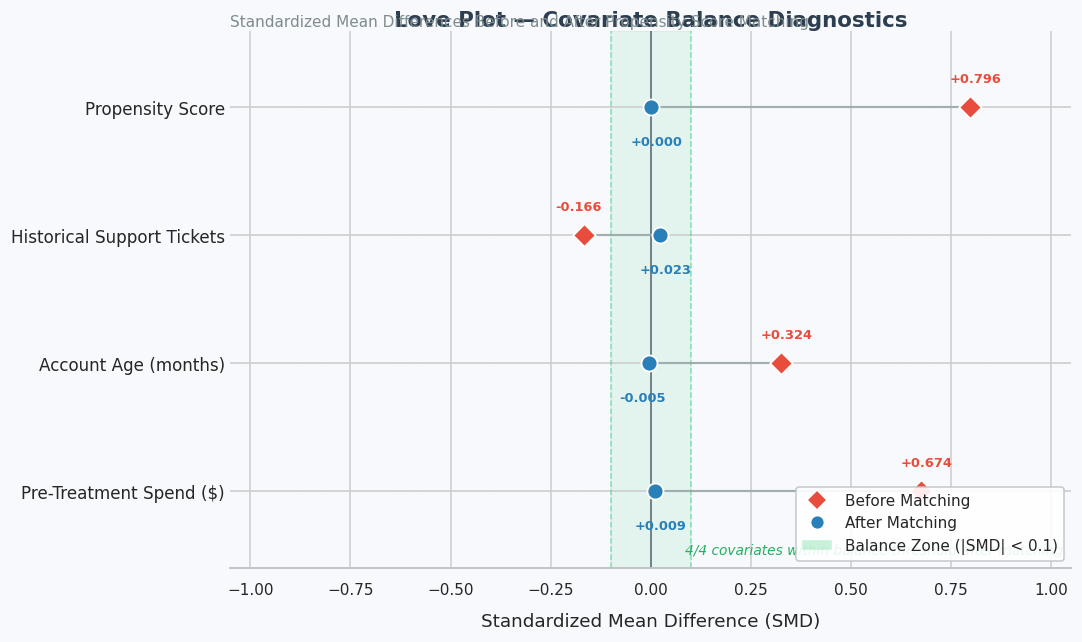

In [18]:
# ── Build df_unmatched and df_matched AFTER pscore exists on df ──────────────
# df already has 'pscore' from the logistic regression cell above.
# df_unmatched = full dataset (pscore included)
# df_matched   = treated rows + their matched controls (pscore included)

df_unmatched = df.copy()
df_matched   = pd.concat([subscribers, matched_controls], ignore_index=True)

# ── Love Plot ─────────────────────────────────────────────────────────────────
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

TREATMENT_COL = 'subscriber'
COVARIATES    = ['pre_spend', 'account_age', 'support_tickets', 'pscore']
LABELS = {
    'pre_spend'       : 'Pre-Treatment Spend ($)',
    'account_age'     : 'Account Age (months)',
    'support_tickets' : 'Historical Support Tickets',
    'pscore'          : 'Propensity Score',
}
THRESHOLD = 0.1

def standardized_mean_diff(treated_series, control_series):
    mean_diff = treated_series.mean() - control_series.mean()
    pooled_sd = np.sqrt((treated_series.std()**2 + control_series.std()**2) / 2)
    return mean_diff / pooled_sd

def compute_smd_table(df, covariates, treatment_col):
    treated = df[df[treatment_col] == 1]
    control = df[df[treatment_col] == 0]
    return {cov: standardized_mean_diff(treated[cov], control[cov]) for cov in covariates}

smd_before = compute_smd_table(df_unmatched, COVARIATES, TREATMENT_COL)
smd_after  = compute_smd_table(df_matched,   COVARIATES, TREATMENT_COL)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#F7F9FC')
ax.set_facecolor('#F7F9FC')

y_positions = np.arange(len(COVARIATES))
y_labels    = [LABELS.get(c, c) for c in COVARIATES]

ax.axvspan(-THRESHOLD, THRESHOLD, color='#2ECC71', alpha=0.10, zorder=0)
ax.axvline(0,          color='#2C3E50', linewidth=1.2, linestyle='-',  zorder=1, alpha=0.6)
ax.axvline(-THRESHOLD, color='#2ECC71', linewidth=1.0, linestyle='--', alpha=0.5, zorder=1)
ax.axvline( THRESHOLD, color='#2ECC71', linewidth=1.0, linestyle='--', alpha=0.5, zorder=1)

for y in y_positions:
    ax.axhline(y, color='#BDC3C7', linewidth=0.5, linestyle=':', zorder=0, alpha=0.7)

COLOR_BEFORE = '#E74C3C'
COLOR_AFTER  = '#2980B9'

for i, cov in enumerate(COVARIATES):
    before = smd_before[cov]
    after  = smd_after[cov]

    ax.plot([before, after], [i, i], color='#95A5A6', linewidth=1.4, zorder=2, alpha=0.8)
    ax.scatter(before, i, color=COLOR_BEFORE, s=110, zorder=4, edgecolors='white', linewidths=1.2, marker='D')
    ax.scatter(after,  i, color=COLOR_AFTER,  s=110, zorder=4, edgecolors='white', linewidths=1.2, marker='o')

    offset = 0.015
    ax.text(before + (offset if before >= 0 else -offset), i + 0.17,
            f'{before:+.3f}', fontsize=8.5, color=COLOR_BEFORE,
            ha='center', va='bottom', fontweight='bold')
    ax.text(after  + (offset if after  >= 0 else -offset), i - 0.22,
            f'{after:+.3f}',  fontsize=8.5, color=COLOR_AFTER,
            ha='center', va='top',    fontweight='bold')

ax.set_yticks(y_positions)
ax.set_yticklabels(y_labels, fontsize=11)
ax.set_xlabel('Standardized Mean Difference (SMD)', fontsize=12, labelpad=10)
ax.set_xlim(-1.05, 1.05)
ax.set_ylim(-0.6, len(COVARIATES) - 0.4)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', length=0)

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#BDC3C7')

legend_elements = [
    mlines.Line2D([0],[0], marker='D', color='w', markerfacecolor=COLOR_BEFORE,
                  markersize=9, label='Before Matching', markeredgecolor='white'),
    mlines.Line2D([0],[0], marker='o', color='w', markerfacecolor=COLOR_AFTER,
                  markersize=9, label='After Matching',  markeredgecolor='white'),
    mpatches.Patch(facecolor='#2ECC71', alpha=0.25, label=f'Balance Zone (|SMD| < {THRESHOLD})'),
]
ax.legend(handles=legend_elements, loc='lower right', frameon=True,
          framealpha=0.9, fontsize=10, edgecolor='#BDC3C7')

ax.set_title('Love Plot — Covariate Balance Diagnostics',
             fontsize=14, fontweight='bold', pad=14, color='#2C3E50')
ax.set_title('Standardized Mean Differences Before and After Propensity Score Matching',
             fontsize=10, color='#7F8C8D', pad=2, loc='left')

n_balanced = sum(abs(v) < THRESHOLD for v in smd_after.values())
ax.text(0.99, 0.02, f'{n_balanced}/{len(COVARIATES)} covariates within balance threshold after matching',
        transform=ax.transAxes, fontsize=9, color='#27AE60',
        ha='right', va='bottom', style='italic')

plt.tight_layout()
plt.show()